In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
import warnings
warnings.filterwarnings('ignore')
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder, MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix,classification_report
from sklearn.neighbors import KNeighborsClassifier

In [18]:

pd.set_option("display.max_columns", None)  
pd.set_option("display.max_rows", None)    
pd.set_option("display.width", None)        


In [19]:
df = pd.read_csv('loan_data.csv')
df.head()  

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [21]:
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [24]:
columns = df.columns
for column in columns:
    print(f"Unique values in '{column}': {df[column].unique()}\n")

Unique values in 'person_age': [ 22.  21.  25.  23.  24.  26. 144. 123.  20.  32.  34.  29.  33.  28.
  35.  31.  27.  30.  36.  40.  50.  45.  37.  39.  44.  43.  41.  46.
  38.  47.  42.  48.  49.  58.  65.  51.  53.  66.  61.  54.  57.  59.
  62.  60.  55.  52.  64.  70.  78.  69.  56.  73.  63.  94.  80.  84.
  76.  67. 116. 109.]

Unique values in 'person_gender': ['female' 'male']

Unique values in 'person_education': ['Master' 'High School' 'Bachelor' 'Associate' 'Doctorate']

Unique values in 'person_income': [71948. 12282. 12438. ... 31924. 56942. 33164.]

Unique values in 'person_emp_exp': [  0   3   1   5   4   2   7   6 125   8 121 101 100  12  10   9  14  13
  11  15  16  17  19  28  25  18  24  22  20  23  21  31  26  27  29  32
  30 124  40  43  33  44  34  42  37  45  36  41  47  38  39  35  57  46
  49  48  50  76  62  61  58  93  85]

Unique values in 'person_home_ownership': ['RENT' 'OWN' 'MORTGAGE' 'OTHER']

Unique values in 'loan_amnt': [35000.  1000.  5500. ... 12

In [25]:
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    print(f"Value counts for '{column}':\n{df[column].value_counts()}\n")

Value counts for 'person_gender':
person_gender
male      24841
female    20159
Name: count, dtype: int64

Value counts for 'person_education':
person_education
Bachelor       13399
Associate      12028
High School    11972
Master          6980
Doctorate        621
Name: count, dtype: int64

Value counts for 'person_home_ownership':
person_home_ownership
RENT        23443
MORTGAGE    18489
OWN          2951
OTHER         117
Name: count, dtype: int64

Value counts for 'loan_intent':
loan_intent
EDUCATION            9153
MEDICAL              8548
VENTURE              7819
PERSONAL             7552
DEBTCONSOLIDATION    7145
HOMEIMPROVEMENT      4783
Name: count, dtype: int64

Value counts for 'previous_loan_defaults_on_file':
previous_loan_defaults_on_file
Yes    22858
No     22142
Name: count, dtype: int64



In [26]:
df['loan_status'].value_counts()

loan_status
0    35000
1    10000
Name: count, dtype: int64

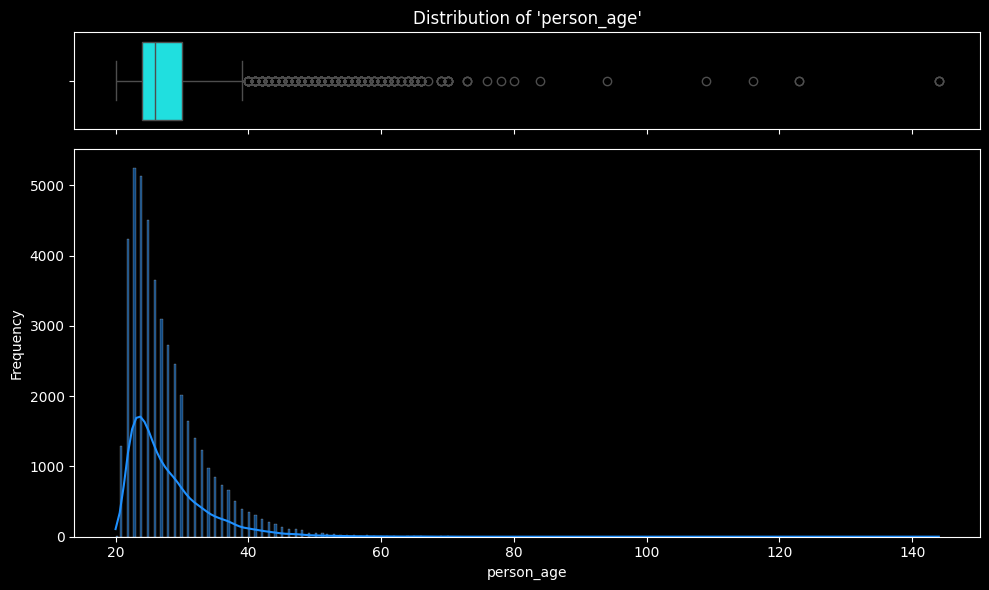

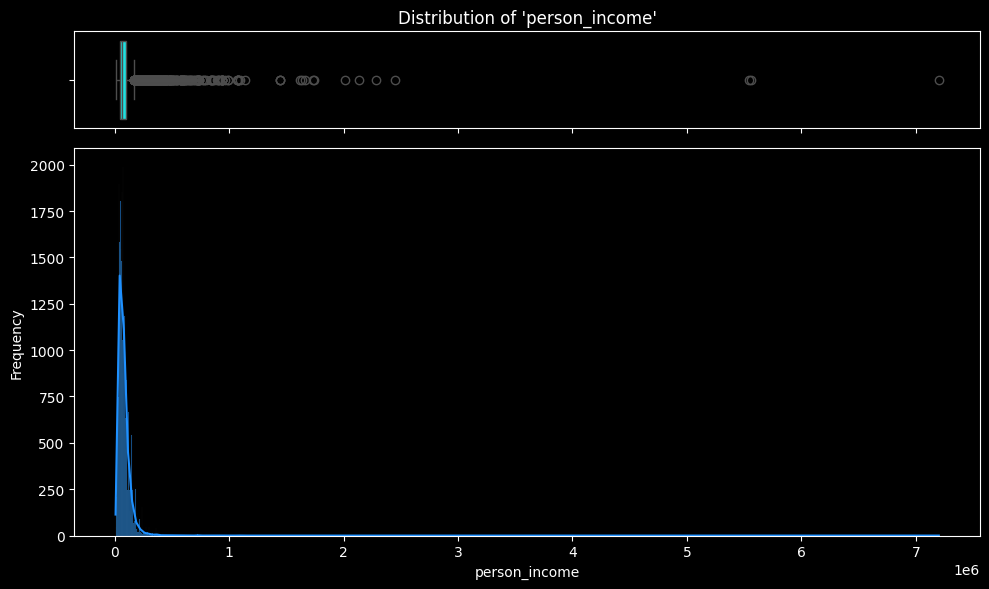

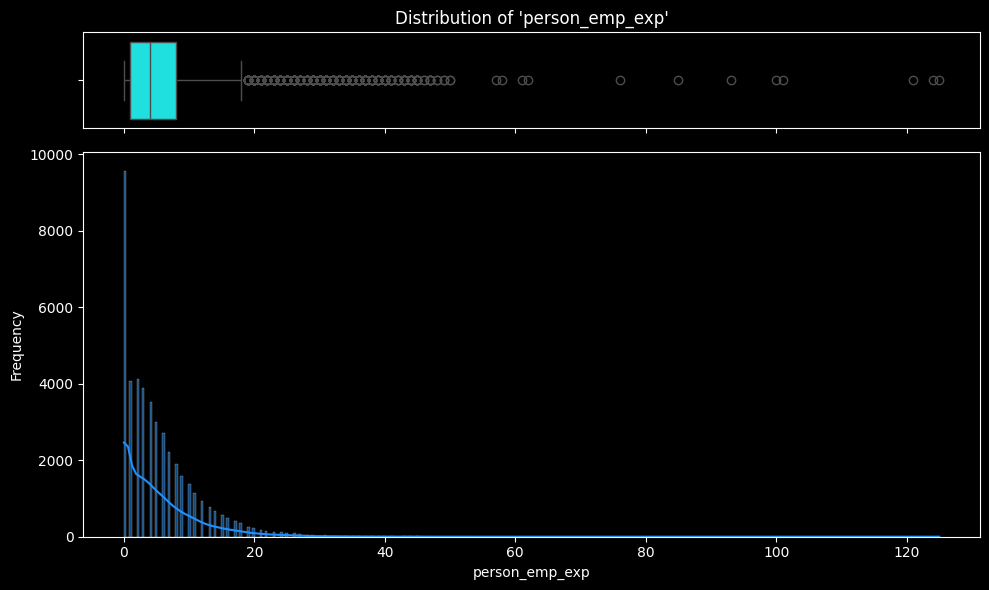

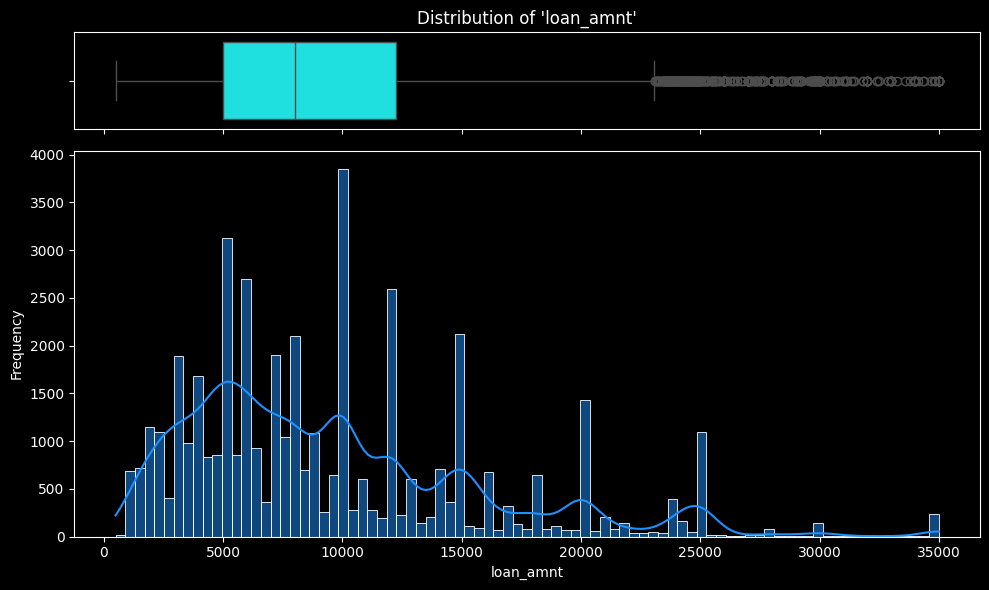

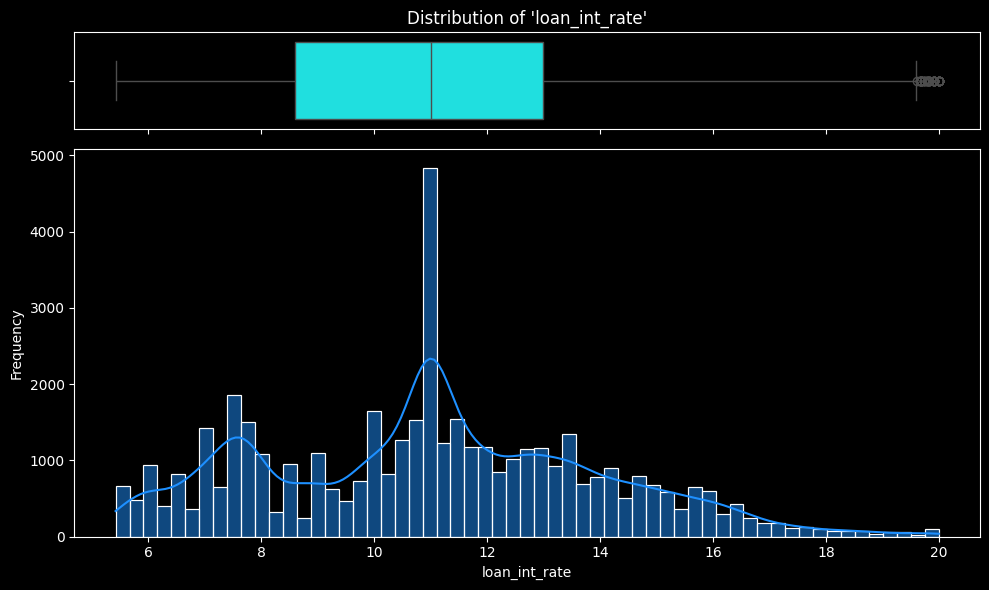

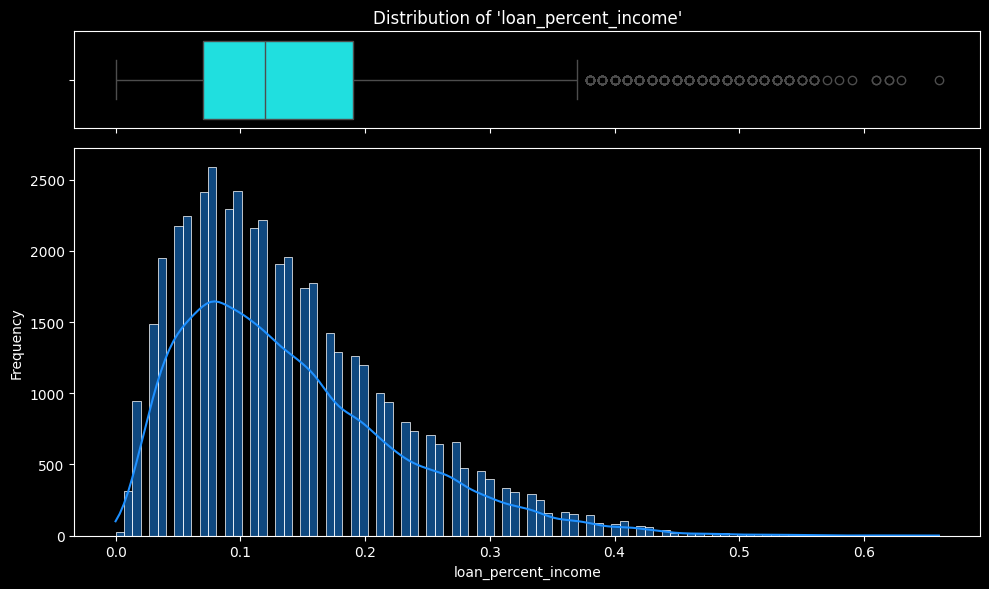

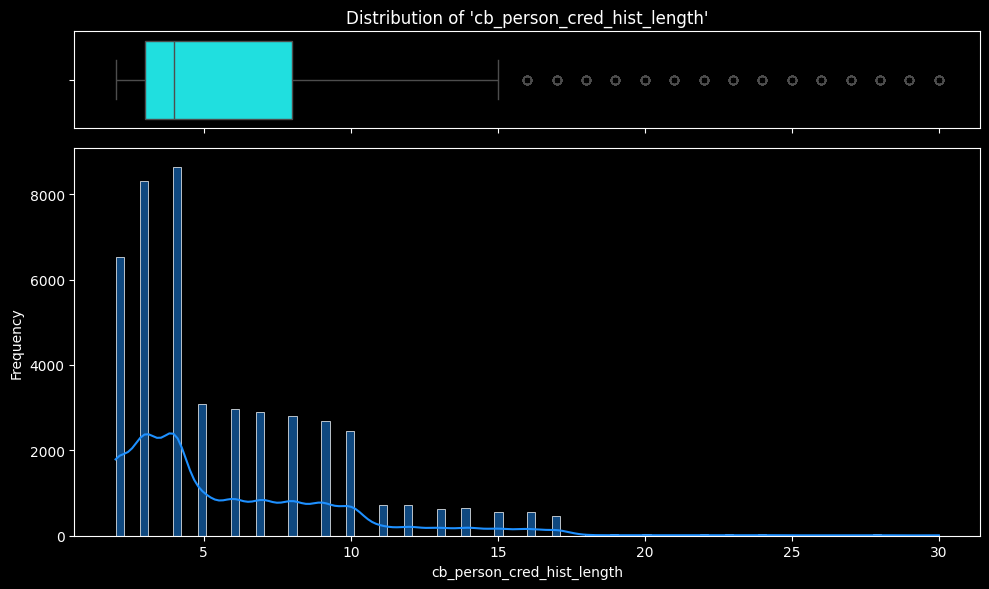

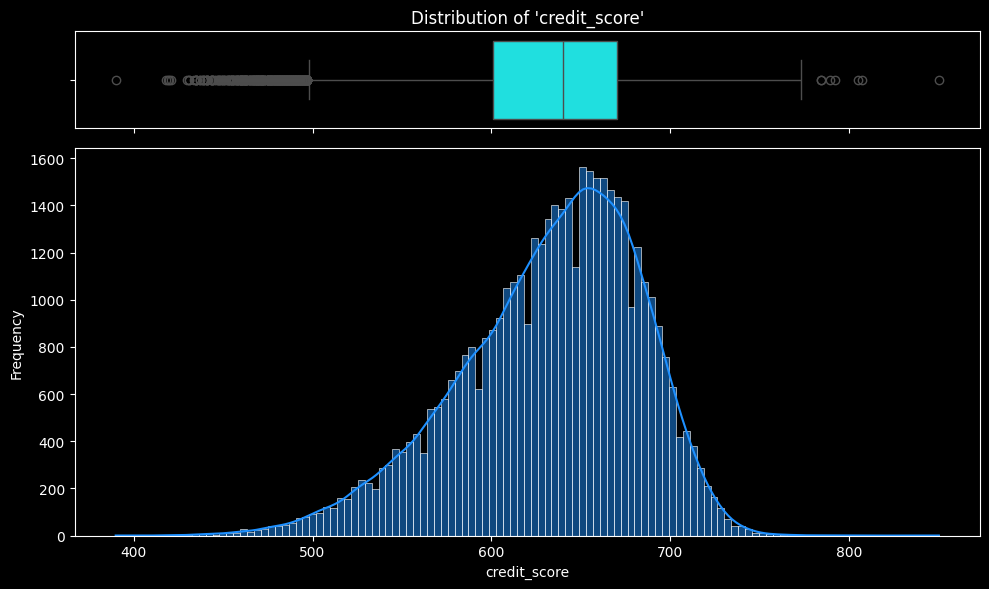

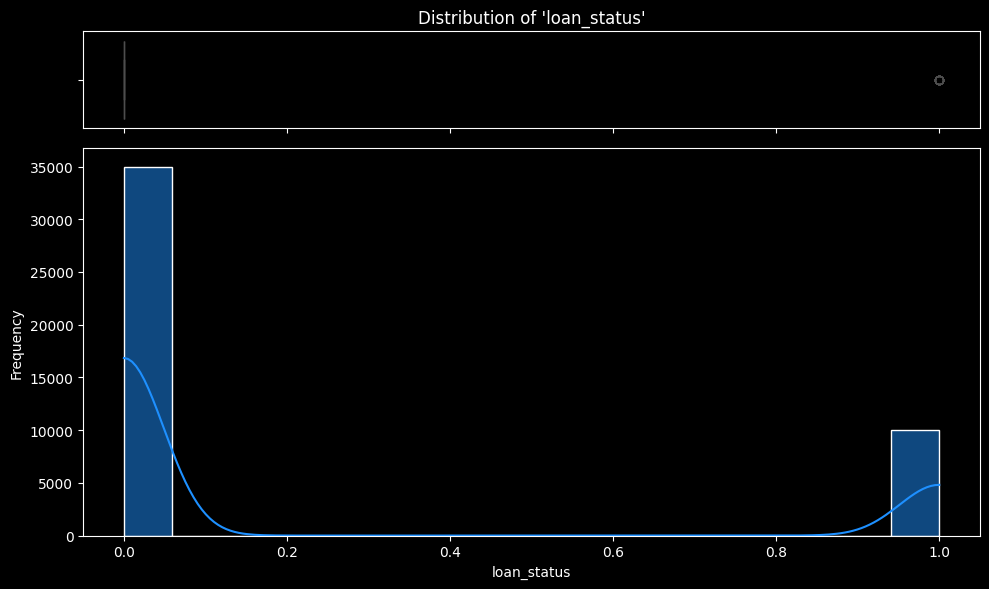

In [27]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

plt.style.use("dark_background")
sns.set_palette("Blues")

for column in numeric_columns:
    fig, axes = plt.subplots(
        2, 1,
        figsize=(10, 6),
        gridspec_kw={"height_ratios": [1, 4]},
        sharex=True
    )

    sns.boxplot(x=df[column], ax=axes[0], color="cyan")
    sns.histplot(df[column], kde=True, ax=axes[1], color="dodgerblue")

    axes[0].set_title(f"Distribution of '{column}'", color="white")
    axes[0].set_xlabel("")
    axes[1].set_xlabel(column, color="white")
    axes[1].set_ylabel("Frequency", color="white")

    for ax in axes:
        ax.tick_params(colors="white")
        ax.set_facecolor("black")

    fig.patch.set_facecolor("black")
    plt.tight_layout()
    plt.show()



In [28]:
q1 = df['loan_amnt'].quantile(0.25)
q3 = df['loan_amnt'].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
outliers = df[(df['loan_amnt'] < lower_bound) | (df['loan_amnt'] > upper_bound)]
outliers.head(20)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
6,26.0,female,Bachelor,93471.0,1,RENT,35000.0,EDUCATION,12.42,0.37,3.0,701,No,1
7,24.0,female,High School,95550.0,5,RENT,35000.0,MEDICAL,11.11,0.37,4.0,585,No,1
8,24.0,female,Associate,100684.0,3,RENT,35000.0,PERSONAL,8.90,0.35,2.0,544,No,1
10,22.0,female,High School,102985.0,0,RENT,35000.0,VENTURE,10.37,0.34,4.0,621,No,1
12,23.0,male,Bachelor,114860.0,3,RENT,35000.0,VENTURE,7.90,0.30,2.0,573,No,1
13,26.0,male,Master,130713.0,0,RENT,35000.0,EDUCATION,18.39,0.27,4.0,708,No,1
14,23.0,female,Associate,138998.0,0,RENT,35000.0,EDUCATION,7.90,0.25,4.0,583,No,0


In [29]:
gender_loan=df.groupby('person_gender')['loan_amnt'].mean().sort_index(ascending=False)
print(gender_loan)


person_gender
male      9643.722837
female    9508.525770
Name: loan_amnt, dtype: float64


<Axes: xlabel='loan_status_label'>

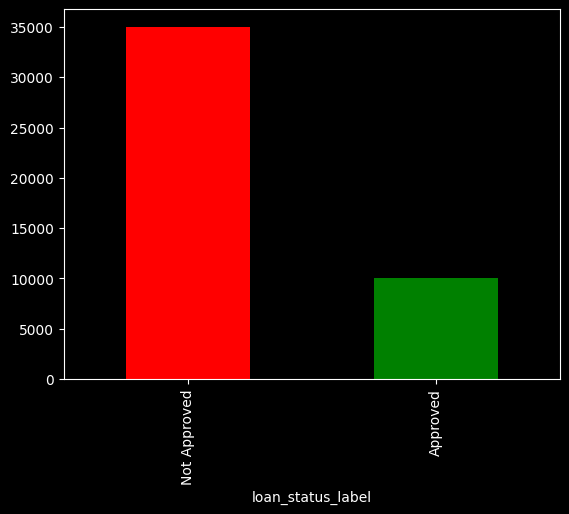

In [30]:
df["loan_status_label"] = df["loan_status"].map({0: "Not Approved", 1: "Approved"})
df["loan_status_label"].value_counts().plot(kind="bar", color=["red", "green"])

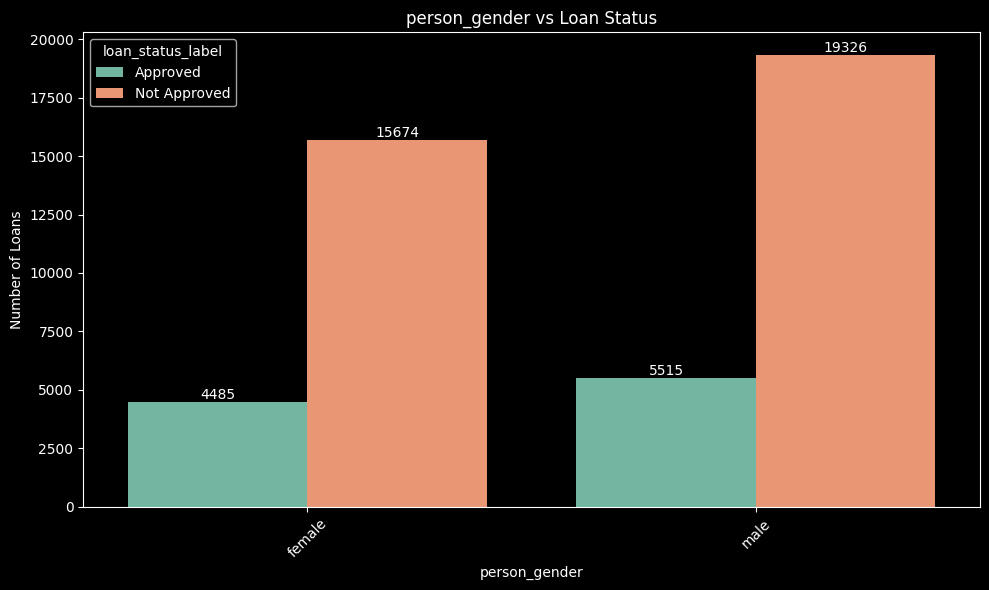

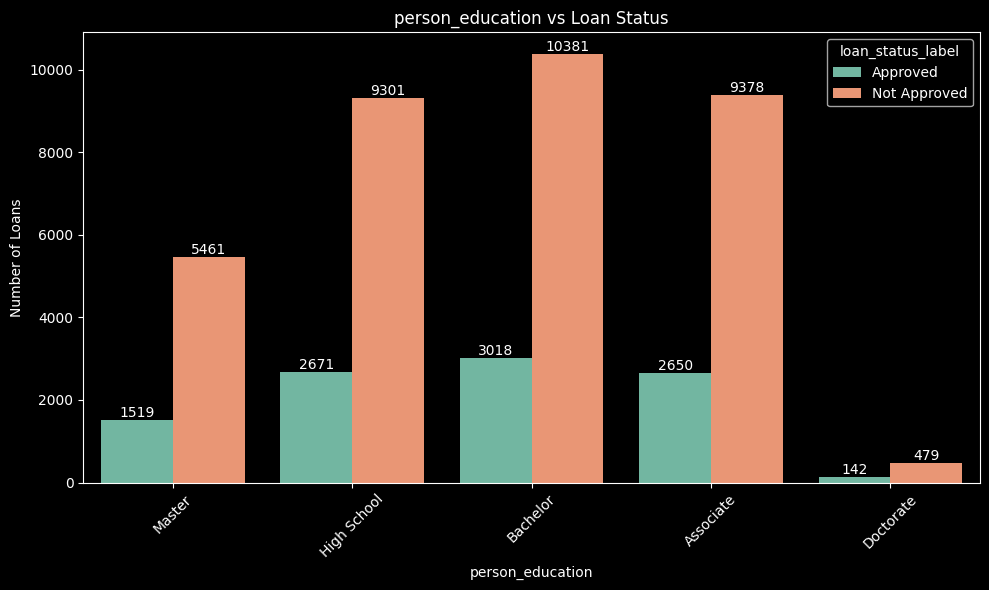

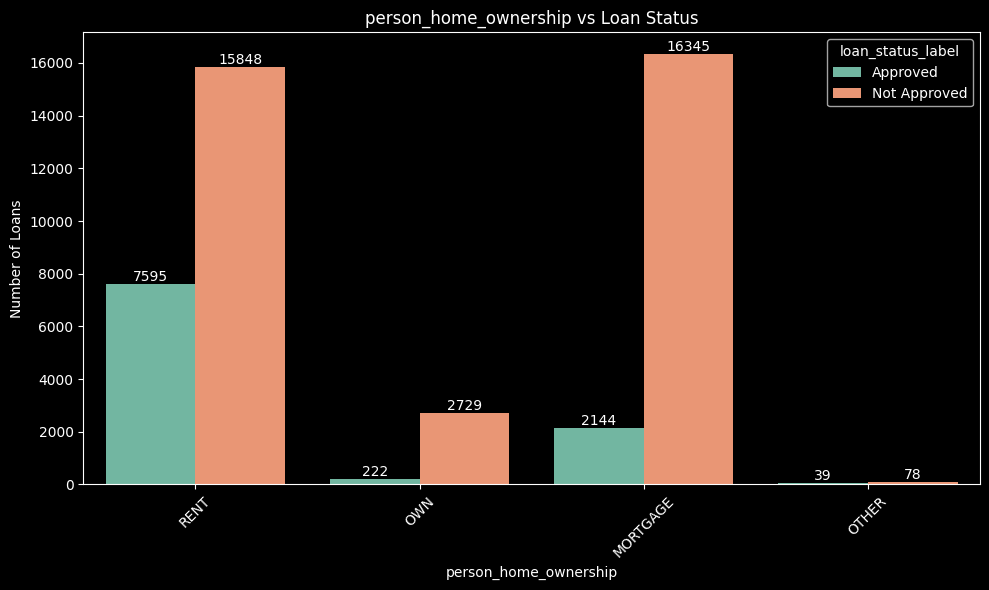

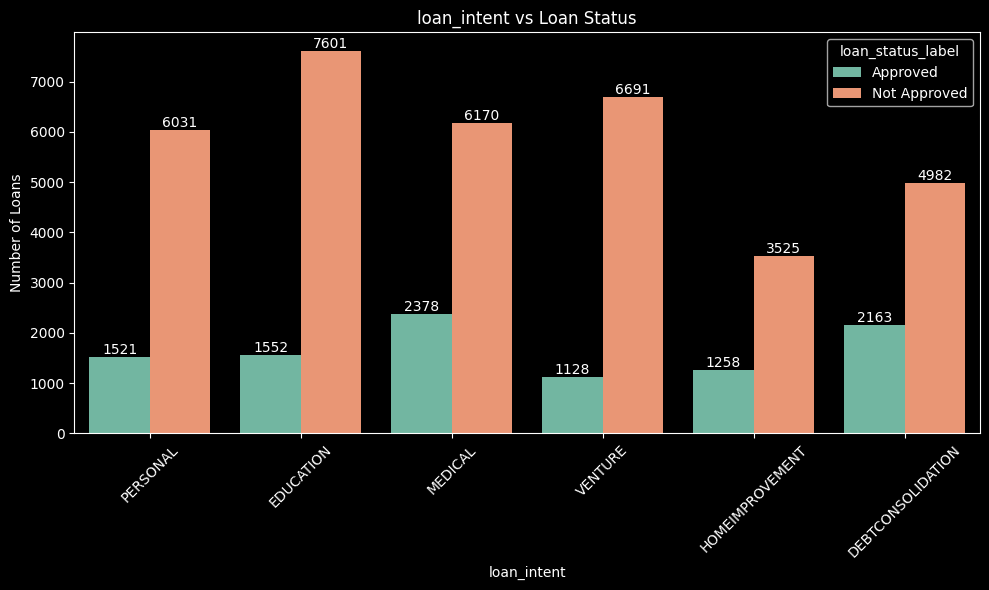

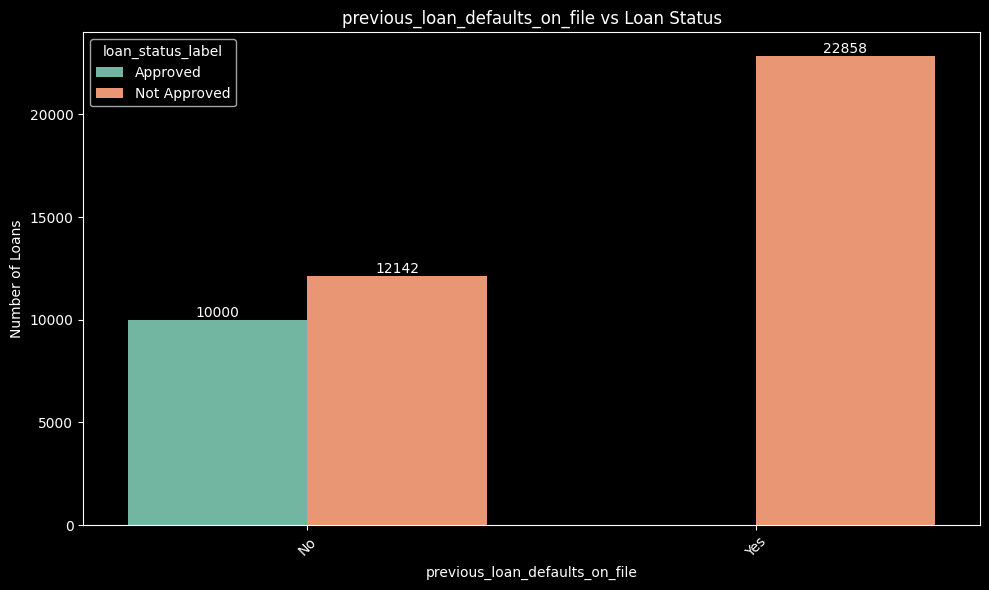

In [31]:
plt.style.use("dark_background")

categorical_columns = df.select_dtypes(include="object").columns.tolist()

if "loan_status_label" in categorical_columns:
    categorical_columns.remove("loan_status_label")

for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    
    ax = sns.countplot(
        data=df,
        x=column,
        hue="loan_status_label",
        palette="Set2"
    )

    plt.title(f"{column} vs Loan Status", color="white")
    plt.xlabel(column, color="white")
    plt.ylabel("Number of Loans", color="white")
    plt.xticks(rotation=45, color="white")
    plt.yticks(color="white")

    for container in ax.containers:
        ax.bar_label(container, color="white")

    ax.set_facecolor("black")
    plt.gcf().patch.set_facecolor("black")
    plt.tight_layout()
    plt.show()




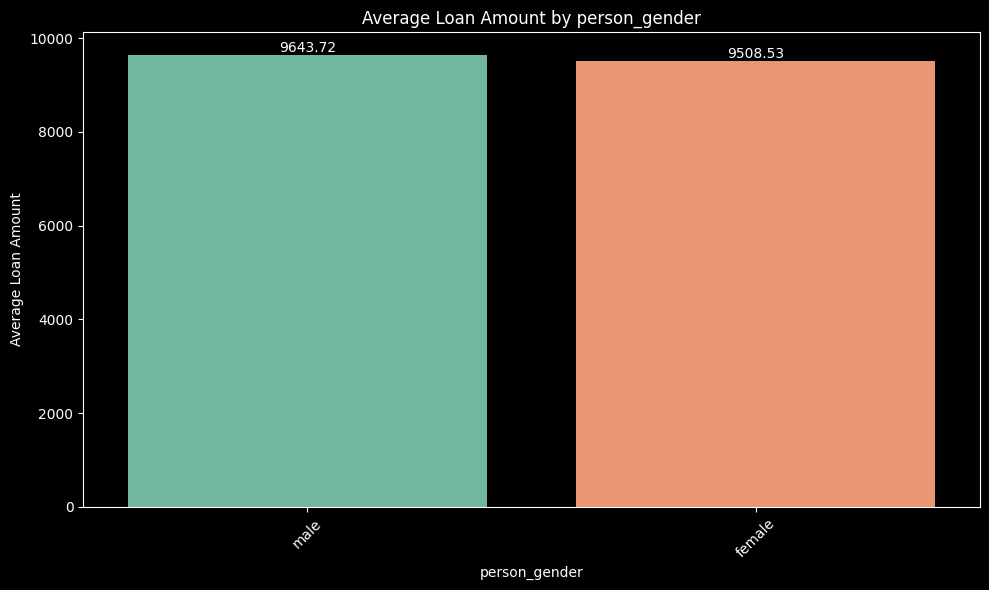

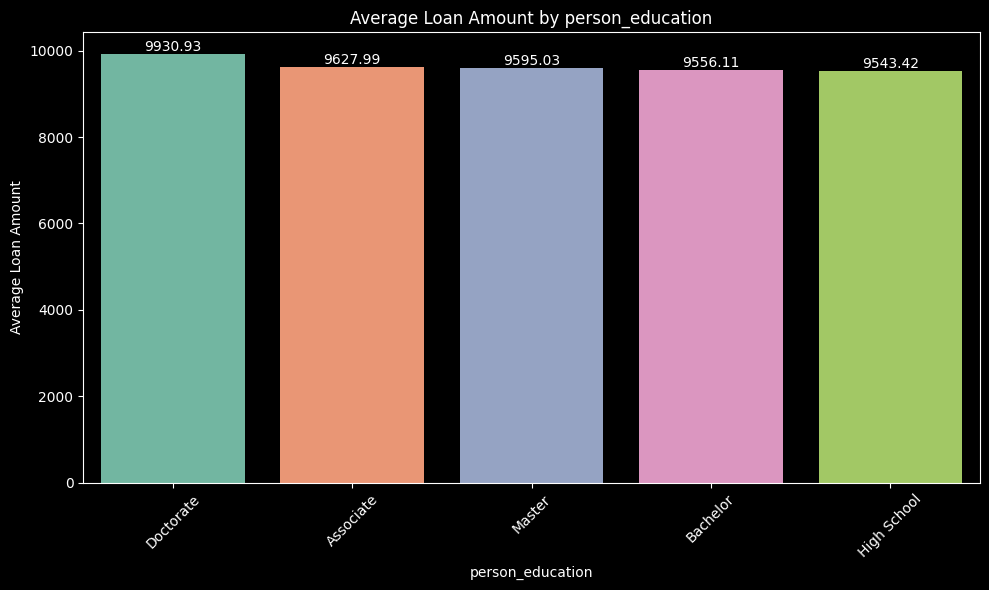

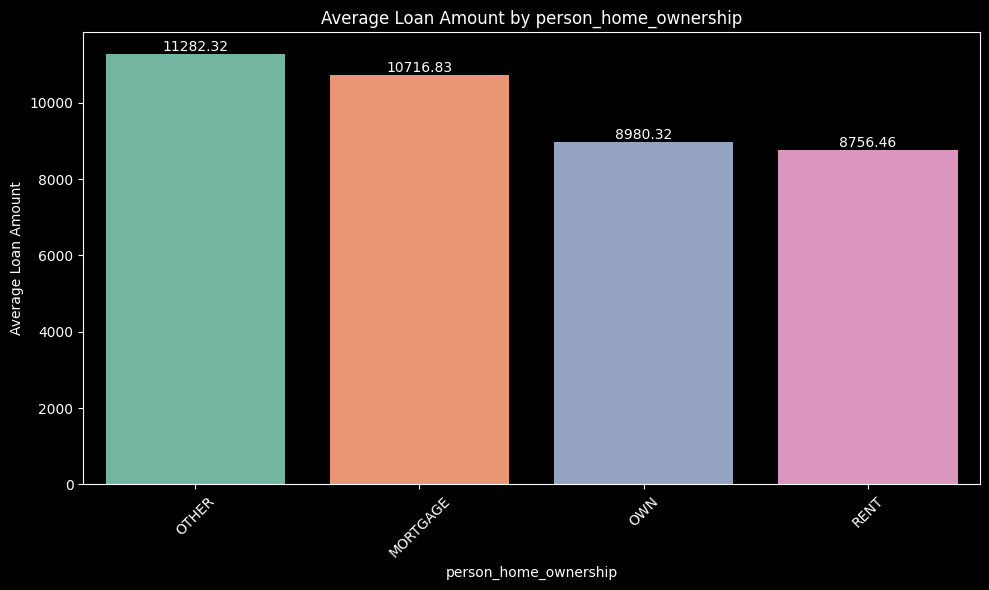

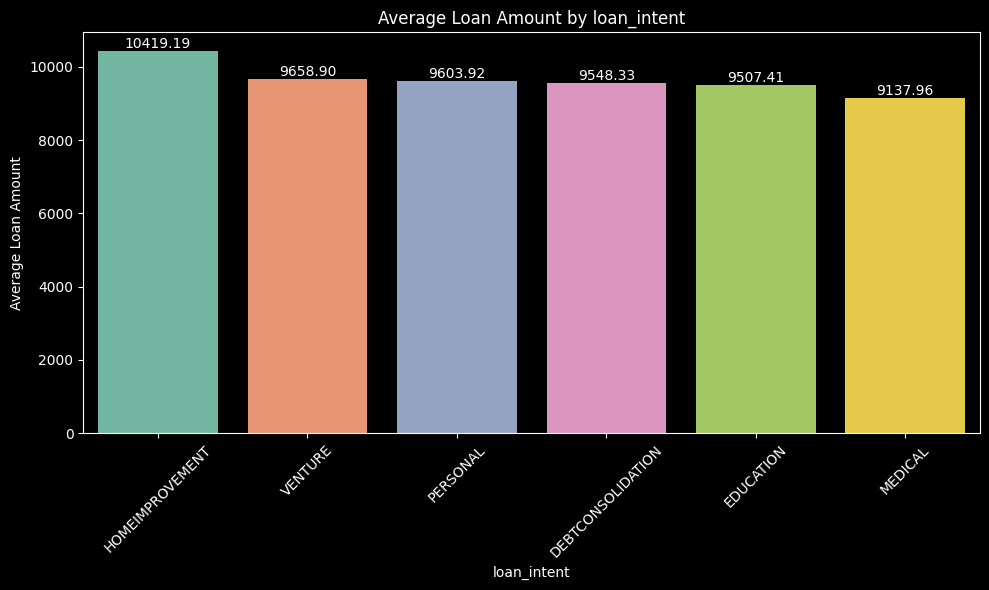

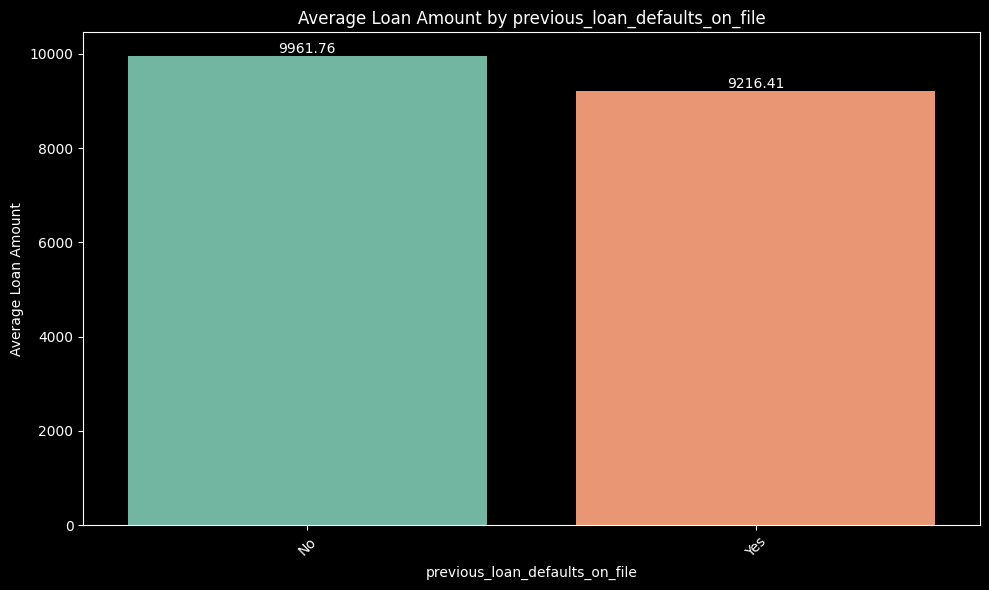

In [32]:
plt.style.use("dark_background")

for column in categorical_columns:
    avg_loan = (
        df.groupby(column)["loan_amnt"]
        .mean()
        .reset_index()
        .sort_values("loan_amnt", ascending=False)
    )

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        data=avg_loan,
        x=column,
        y="loan_amnt",
        palette="Set2"
    )

    plt.title(f"Average Loan Amount by {column}", color="white")
    plt.xlabel(column, color="white")
    plt.ylabel("Average Loan Amount", color="white")
    plt.xticks(rotation=45, color="white")
    plt.yticks(color="white")

    for container in ax.containers:
        ax.bar_label(container, fmt="%.2f", color="white")

    ax.set_facecolor("black")
    plt.gcf().patch.set_facecolor("black")
    plt.tight_layout()
    plt.show()



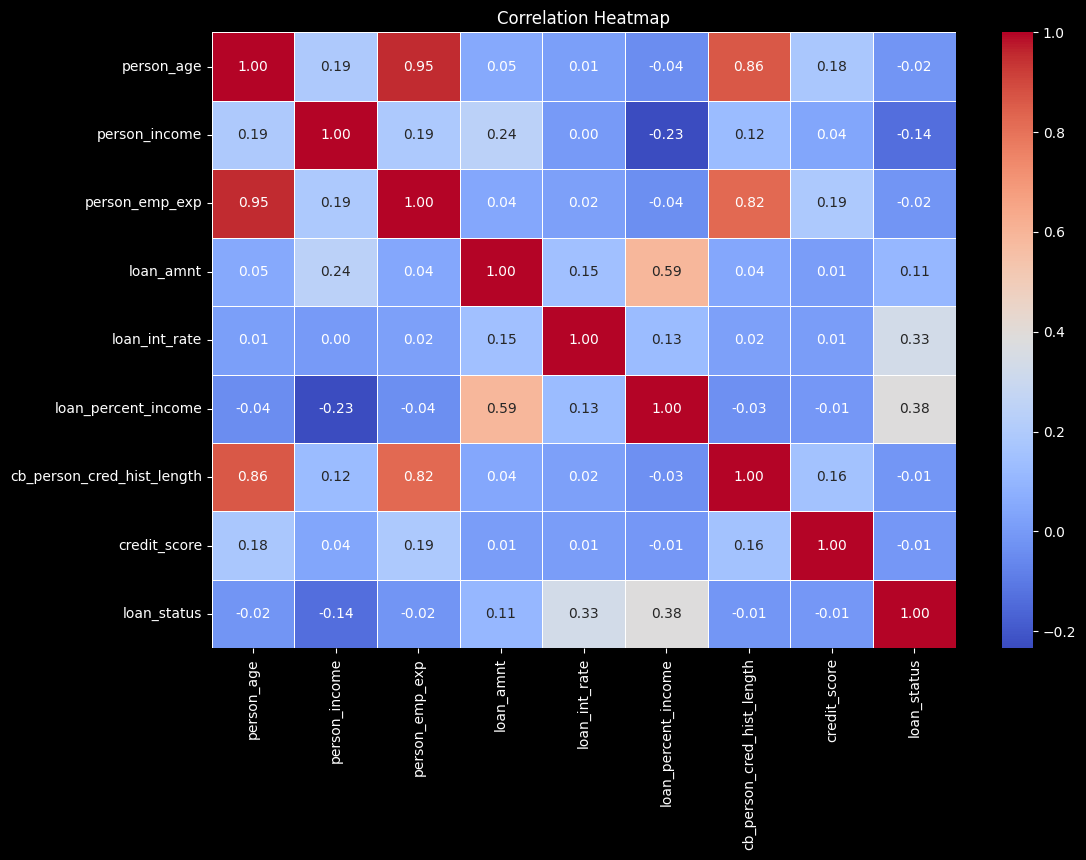

In [33]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()
    

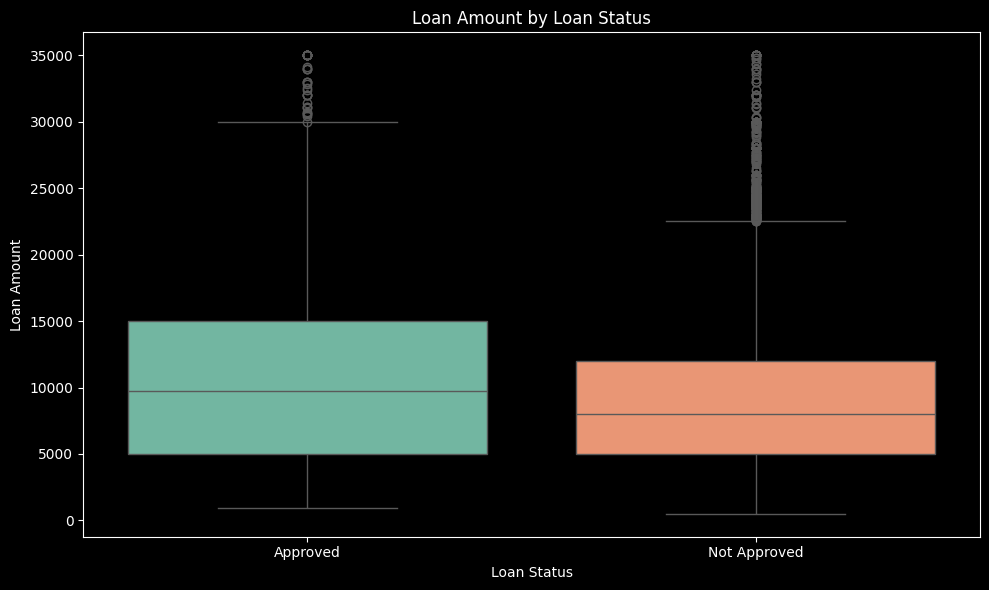

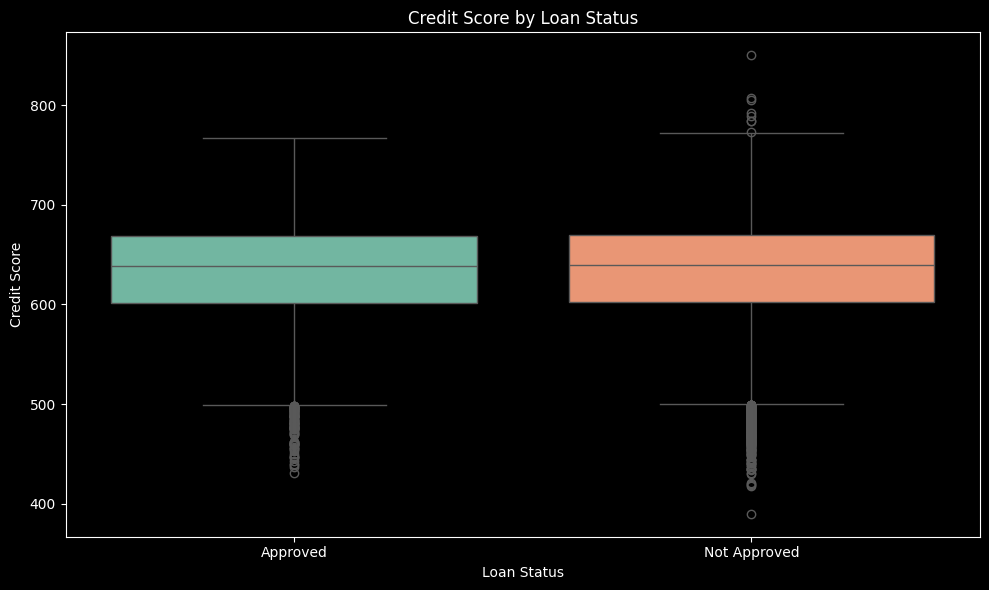

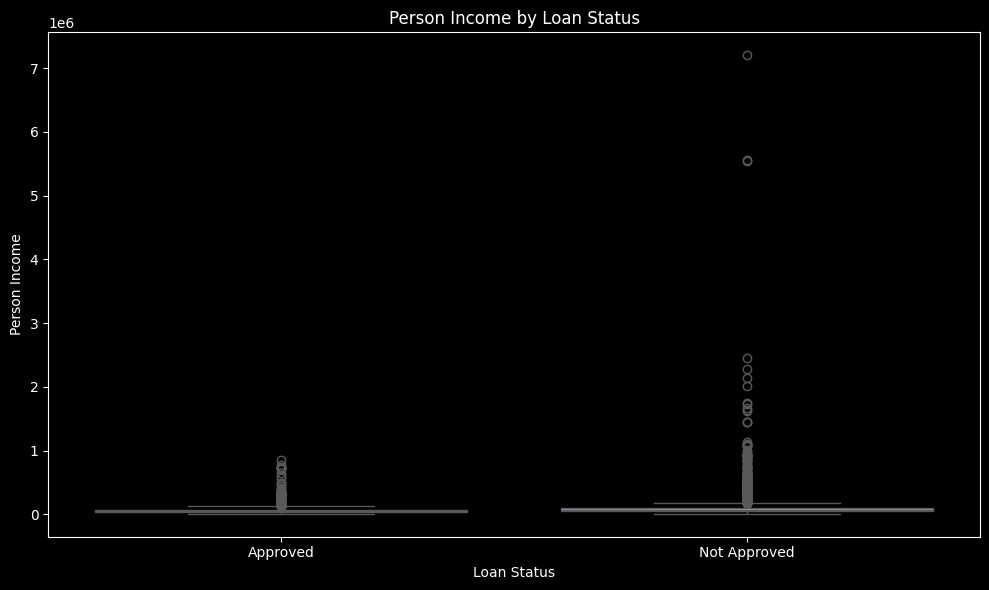

In [34]:
plt.style.use("dark_background")

plots = [
    ("loan_amnt", "Loan Amount by Loan Status", "Loan Amount"),
    ("credit_score", "Credit Score by Loan Status", "Credit Score"),
    ("person_income", "Person Income by Loan Status", "Person Income")
]

for y_col, title, ylabel in plots:
    plt.figure(figsize=(10, 6))
    
    ax = sns.boxplot(
        data=df,
        x="loan_status_label",
        y=y_col,
        hue="loan_status_label",
        palette="Set2",
        legend=False
    )

    plt.title(title, color="white")
    plt.xlabel("Loan Status", color="white")
    plt.ylabel(ylabel, color="white")
    plt.xticks(color="white")
    plt.yticks(color="white")

    ax.set_facecolor("black")
    plt.gcf().patch.set_facecolor("black")
    plt.tight_layout()
    plt.show()



In [35]:
df["income_to_loan_ratio"] = df["person_income"] / (df["loan_amnt"] + 1)
df["loan_per_credit_year"] = df["loan_amnt"] / (df["cb_person_cred_hist_length"] + 1)
df["income_per_emp_year"] = df["person_income"] / (df["person_emp_exp"] + 1)
df["interest_burden"] = df["loan_amnt"] * df["loan_int_rate"]
df["credit_score_x_history"] = df["credit_score"] * df["cb_person_cred_hist_length"]


In [36]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_label,income_to_loan_ratio,loan_per_credit_year,income_per_emp_year,interest_burden,credit_score_x_history
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1,Approved,2.055598,8750.000000,71948.0,560700.0,1683.0
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0,Not Approved,12.269730,333.333333,12282.0,11140.0,1008.0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1,Approved,2.261043,1375.000000,3109.5,70785.0,1905.0
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1,Approved,2.278592,11666.666667,79753.0,533050.0,1350.0
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1,Approved,1.889517,7000.000000,33067.5,499450.0,2344.0


In [37]:
from sklearn.preprocessing import LabelEncoder

df["previous_loan_defaults_on_file"] = df["previous_loan_defaults_on_file"].map({"No": 0, "Yes": 1})
edu_map = {
    "High School": 0,
    "Associate": 1,
    "Bachelor": 2,
    "Master": 3,
    "Doctorate": 4
}

df["person_education"] = df["person_education"].map(edu_map)




In [38]:
df['person_gender'].unique()

array(['female', 'male'], dtype=object)

In [39]:
mapping = {"male": 1, "female": 0}

df["person_gender"] = (
    df["person_gender"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map(mapping)
)

In [40]:
df = pd.get_dummies(
    df,
    columns=["person_home_ownership", "loan_intent"],
    drop_first=True
)

In [41]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status,loan_status_label,income_to_loan_ratio,loan_per_credit_year,income_per_emp_year,interest_burden,credit_score_x_history,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,22.0,0,3,71948.0,0,35000.0,16.02,0.49,3.0,561,0,1,Approved,2.055598,8750.000000,71948.0,560700.0,1683.0,False,False,True,False,False,False,True,False
1,21.0,0,0,12282.0,0,1000.0,11.14,0.08,2.0,504,1,0,Not Approved,12.269730,333.333333,12282.0,11140.0,1008.0,False,True,False,True,False,False,False,False
2,25.0,0,0,12438.0,3,5500.0,12.87,0.44,3.0,635,0,1,Approved,2.261043,1375.000000,3109.5,70785.0,1905.0,False,False,False,False,False,True,False,False
3,23.0,0,2,79753.0,0,35000.0,15.23,0.44,2.0,675,0,1,Approved,2.278592,11666.666667,79753.0,533050.0,1350.0,False,False,True,False,False,True,False,False
4,24.0,1,3,66135.0,1,35000.0,14.27,0.53,4.0,586,0,1,Approved,1.889517,7000.000000,33067.5,499450.0,2344.0,False,False,True,False,False,True,False,False


In [42]:
x = df.drop(columns=["loan_status", "loan_status_label"])
y = df["loan_status"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score",
    "income_to_loan_ratio",
    "loan_per_credit_year",
    "income_per_emp_year",
    "interest_burden",
    "credit_score_x_history",
    
]

scaler = StandardScaler()

x_train.loc[:, numeric_cols] = scaler.fit_transform(x_train[numeric_cols])
x_test.loc[:, numeric_cols] = scaler.transform(x_test[numeric_cols])

model = LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)

In [43]:

y_train_pred = model.predict(x_train)
y_test_pred  = model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.8973333333333333
Test Accuracy: 0.8944444444444445


In [44]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))  

Accuracy: 0.8944444444444445
Confusion Matrix:
 [[6556  434]
 [ 516 1494]]


In [45]:
print(classification_report(y_test, y_pred)
      )

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      6990
           1       0.77      0.74      0.76      2010

    accuracy                           0.89      9000
   macro avg       0.85      0.84      0.85      9000
weighted avg       0.89      0.89      0.89      9000



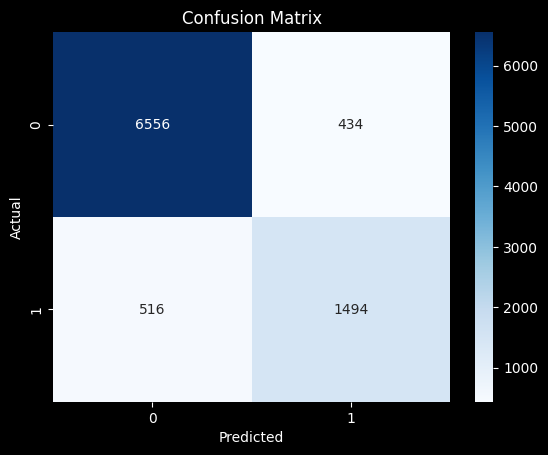

In [46]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [47]:
model = KNeighborsClassifier(n_neighbors=11)
model.fit(x_train, y_train)
y_pred= model.predict(x_test)

In [48]:

y_train_pred = model.predict(x_train)
y_test_pred  = model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.9145555555555556
Test Accuracy: 0.8961111111111111


In [49]:

y_train_pred = model.predict(x_train)
y_test_pred  = model.predict(x_test)

print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

Train Accuracy: 0.9145555555555556
Test Accuracy: 0.8961111111111111


In [50]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.91      0.96      0.94      6990
           1       0.84      0.66      0.74      2010

    accuracy                           0.90      9000
   macro avg       0.87      0.81      0.84      9000
weighted avg       0.89      0.90      0.89      9000



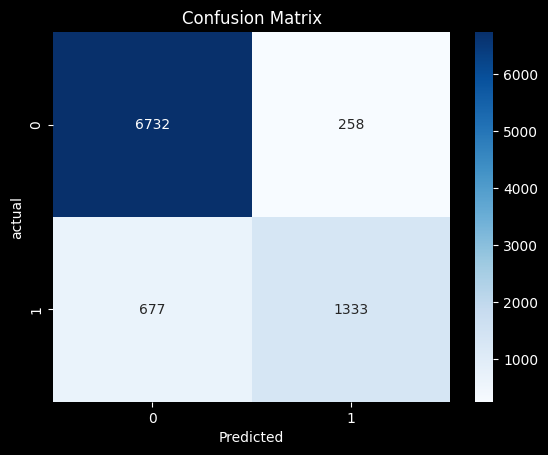

In [51]:

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel('actual')
plt.show()